In [86]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

In [87]:
# collection data
df = pd.read_csv("Social_Network_Ads.csv")
df
checking_null_values = df.isnull().sum()
checking_duplicate_values = df.duplicated().sum()
checking_duplicate_values 

np.int64(33)

In [88]:
df_clean = df.drop_duplicates()
df_clean

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


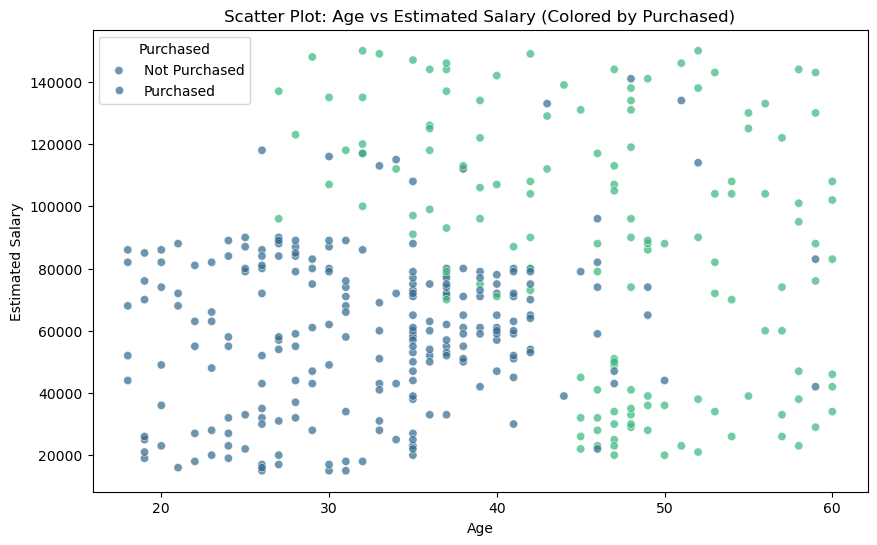

In [89]:
# Visualizing the dataset
# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Age', y='EstimatedSalary', hue='Purchased', palette='viridis', alpha=0.7)

# Adding labels and title
plt.title('Scatter Plot: Age vs Estimated Salary (Colored by Purchased)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')

# Updating the legend labels
plt.legend(title='Purchased', labels=['Not Purchased', 'Purchased'])
plt.show()

In [90]:
# Feature selection
X = df.drop(columns="Purchased")
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [91]:
y = df["Purchased"]
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [92]:
# Splitting of dataset into training and testing (randomly)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

In [93]:
# Using KNN Model
model = KNN(n_neighbors=2)

In [94]:
# Training the Model
model.fit(X_train,y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [95]:
predicted_y = model.predict(X_test)

In [96]:
predicted_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

In [97]:
result = accuracy_score(predicted_y, y_test)
result

0.7125

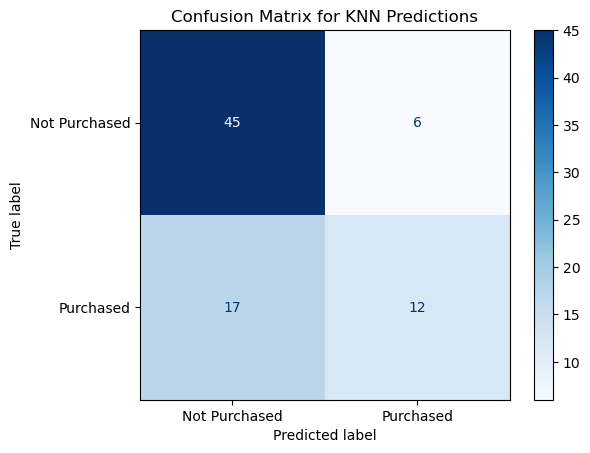

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, predicted_y)

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for KNN Predictions')
plt.show()